In [15]:
import numpy as np
import pint
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
unit = pint.UnitRegistry()

magnitude = lambda x: x.magnitude if isinstance(x, pint.Quantity) else x
tounit = lambda x: lambda y: y.to(x)
assign_unit = lambda x: lambda y: y * x
assign_quantitiy = lambda t, quantity: unit.Quantity(t, quantity)

In [16]:
data1 = pd.read_csv("../DATA/data_table1.csv")
data2 = pd.read_csv("../DATA/data_table2.csv")

In [17]:
for d in (data1, data2):
    d.columns = [c.strip() for c in d.columns]
    if "t(s)" in d.columns: d.rename(columns={"t(s)": "Time (s)"}, inplace=True)
    if "T(C)" in d.columns: d.rename(columns={"T(C)": "Temperature (C)"}, inplace=True)
    
    # Apply pint units properly
    d["Time (s)"] = d["Time (s)"].apply(lambda t: assign_quantitiy(t, unit.second))
    d["Temperature (C)"] = d["Temperature (C)"].apply(lambda t: assign_quantitiy(t, unit.degree_Celsius))

data1.head()

,Time (s),Temperature (C)
0,0 second,24 degree_Celsius
1,30 second,25 degree_Celsius
2,60 second,25 degree_Celsius
3,90 second,26 degree_Celsius
4,120 second,27 degree_Celsius


In [18]:
C_band = 4.0 * unit.joule / unit.kelvin
C_th = 4.0 * unit.joule / unit.kelvin
C_accessories = C_band + C_th

params_brass = {
    "m": 0.646 * unit.kilogram, 
    "r": 0.0245 * unit.meter, 
    "F_R": 5.05 * unit.newton, 
    "n": 200 * unit.dimensionless, 
    "theory_c": 385.0 * unit.joule / (unit.kilogram * unit.kelvin)
} 
params_al = {
    "m": 0.438 * unit.kilogram, 
    "r": 0.0240 * unit.meter, 
    "F_R": 1.00 * unit.newton, 
    "n": 200 * unit.dimensionless, 
    "theory_c": 900.0 * unit.joule / (unit.kilogram * unit.kelvin)
}

import os
os.makedirs("../plots", exist_ok=True)

def polynomial_fit_and_plot(df, name, p, save_path):
    """
    Perform baseline fit, calculate thermodynamics quantities, and plot the results.
    """
    # Polyfit requires numerical dimensions
    t = df["Time (s)"].apply(magnitude).to_numpy(dtype=float)
    T = df["Temperature (C)"].apply(magnitude).to_numpy(dtype=float)
    
    # Fit baseline to first 3 points (before heating starts heavily)
    n_base = 3
    a_base, b_base = np.polyfit(t[:n_base], T[:n_base], 1)
    
    i_peak = int(np.argmax(T))
    t_star = t[i_peak]
    T_peak = T[i_peak]
    T_baseline_at_t0 = b_base 
    
    # Temperature change (temperature differences align directly to Kelvins)
    dT = assign_quantitiy(T_peak - T_baseline_at_t0, unit.kelvin)
    
    # Mechanical work W = 2 * pi * r * n * F
    W = (2 * np.pi * p["r"] * p["n"] * p["F_R"]).to(unit.joule)
    
    # Heat capacities
    C_tot = (W / dT).to(unit.joule / unit.kelvin)
    C_cyl = C_tot - C_accessories
    c = (C_cyl / p["m"]).to(unit.joule / (unit.kilogram * unit.kelvin))
    
    Q_theory = (p["m"] * p["theory_c"] * dT + C_accessories * dT).to(unit.joule)
    ratio = magnitude(W / Q_theory)
    
    # Plotting
    plt.figure(figsize=(8, 5))
    plt.plot(t, T, 'o-', label=f'{name} data')
    
    tt = np.linspace(t.min(), t.max(), 100)
    plt.plot(tt, a_base * tt + b_base, '--', label='Baseline fit')
    
    plt.axvline(t_star, color='gray', linestyle=':', label=f't*={t_star:.1f} s')
    plt.plot([t_star, t_star], [b_base + a_base*t_star, T_peak], 'r-', lw=2, label=f'ΔT={magnitude(dT):.2f} K')
    
    plt.title(f"{name}: Temperature vs Time")
    plt.xlabel("Time (s)")
    plt.ylabel("Temperature (°C)")
    plt.legend()
    plt.grid(True)
    plt.savefig(save_path)
    plt.show()
    
    return {
        "Material": name,
        "Delta_T (K)": magnitude(dT),
        "Work (J)": magnitude(W),
        "Specific Heat c (J/kg.K)": magnitude(c),
        "W / Q_theory": ratio
    }

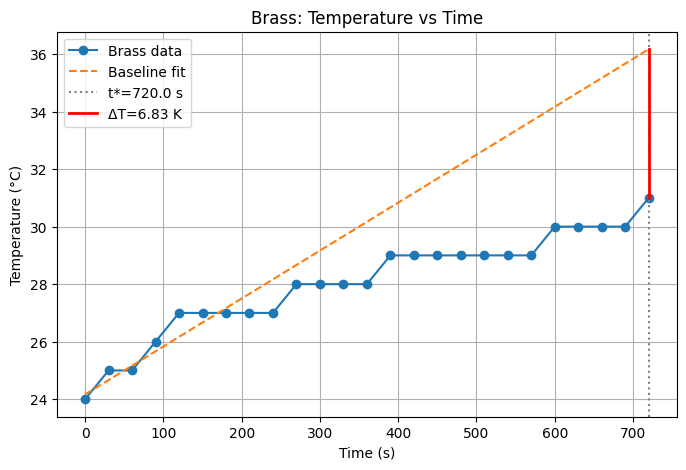

In [19]:
res_brass = polynomial_fit_and_plot(data1, "Brass", params_brass, "../plots/brass_temperature_analysis.png")

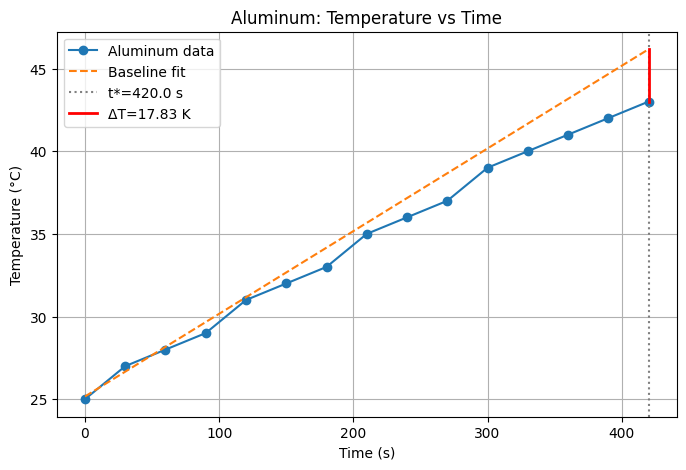

In [20]:
res_al = polynomial_fit_and_plot(data2, "Aluminum", params_al, "../plots/aluminum_temperature_analysis.png")

In [24]:
import os
os.makedirs("../report/tables", exist_ok=True)

results_df = pd.DataFrame([res_brass, res_al])
results_df.to_csv("../report/tables/analysis_results.csv", index=False)

results_df

,Material,Delta_T (K),Work (J),Specific Heat c (J/kg.K),W / Q_theory
0,Brass,6.833333,155.477420,22.837141,0.088632
1,Aluminum,17.833333,30.159289,-14.403710,0.004205
